In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
# Credit Card Fraud Detection using Neural Networks

# IMPORTING REQUIRED MODULES
import numpy as np
print(np.__version__)
import pandas as pd
print(pd.__version__)
import matplotlib.pyplot as plt
import seaborn as sns
print(sns.__version__)
import itertools
import warnings
warnings.filterwarnings("ignore")

2.0.2
2.2.2
0.13.2


In [3]:
# NEURAL NETWORKS MODULES
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn import metrics
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

In [4]:
# KERAS MODULES
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout
from keras.callbacks import Callback
import keras.backend as kb
import tensorflow as tf
print(tf.__version__)

2.19.0


In [5]:
# READING THE DATASET
#dataset = pd.read_csv("/content/gdrive/MyDrive/Credit Card Fraud Detection Dataset 2023/creditcard_2023.csv")
dataset = pd.read_csv("/content/gdrive/MyDrive/2013_impbalanced/creditcard.csv")
print("Dataset Shape: ", dataset.shape)
print("Number of Rows",dataset.shape[0])
print("Number of Columns",dataset.shape[1])
print("Maximum Transaction Value: ", np.max(dataset.Amount))
print("Minimum Transaction Value: ", np.min(dataset.Amount))


Dataset Shape:  (284807, 31)
Number of Rows 284807
Number of Columns 31
Maximum Transaction Value:  25691.16
Minimum Transaction Value:  0.0


In [6]:
print("Few Entries: ")
print(dataset.head())

Few Entries: 
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       

In [7]:
print(dataset.describe())
print(dataset.info())

                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.168375e-15  3.416908e-16 -1.379537e-15  2.074095e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   9.604066e-16  1.487313e-15 -5.556467e-16  1.213481e-16 -2.406331e-15   
std    1.380247e+00  1.332271e+00  1.23709

Class
0    284315
1       492
Name: count, dtype: int64


array([[<Axes: title={'center': 'Time'}>, <Axes: title={'center': 'V1'}>,
        <Axes: title={'center': 'V2'}>, <Axes: title={'center': 'V3'}>,
        <Axes: title={'center': 'V4'}>, <Axes: title={'center': 'V5'}>],
       [<Axes: title={'center': 'V6'}>, <Axes: title={'center': 'V7'}>,
        <Axes: title={'center': 'V8'}>, <Axes: title={'center': 'V9'}>,
        <Axes: title={'center': 'V10'}>, <Axes: title={'center': 'V11'}>],
       [<Axes: title={'center': 'V12'}>, <Axes: title={'center': 'V13'}>,
        <Axes: title={'center': 'V14'}>, <Axes: title={'center': 'V15'}>,
        <Axes: title={'center': 'V16'}>, <Axes: title={'center': 'V17'}>],
       [<Axes: title={'center': 'V18'}>, <Axes: title={'center': 'V19'}>,
        <Axes: title={'center': 'V20'}>, <Axes: title={'center': 'V21'}>,
        <Axes: title={'center': 'V22'}>, <Axes: title={'center': 'V23'}>],
       [<Axes: title={'center': 'V24'}>, <Axes: title={'center': 'V25'}>,
        <Axes: title={'center': 'V26'}>, <

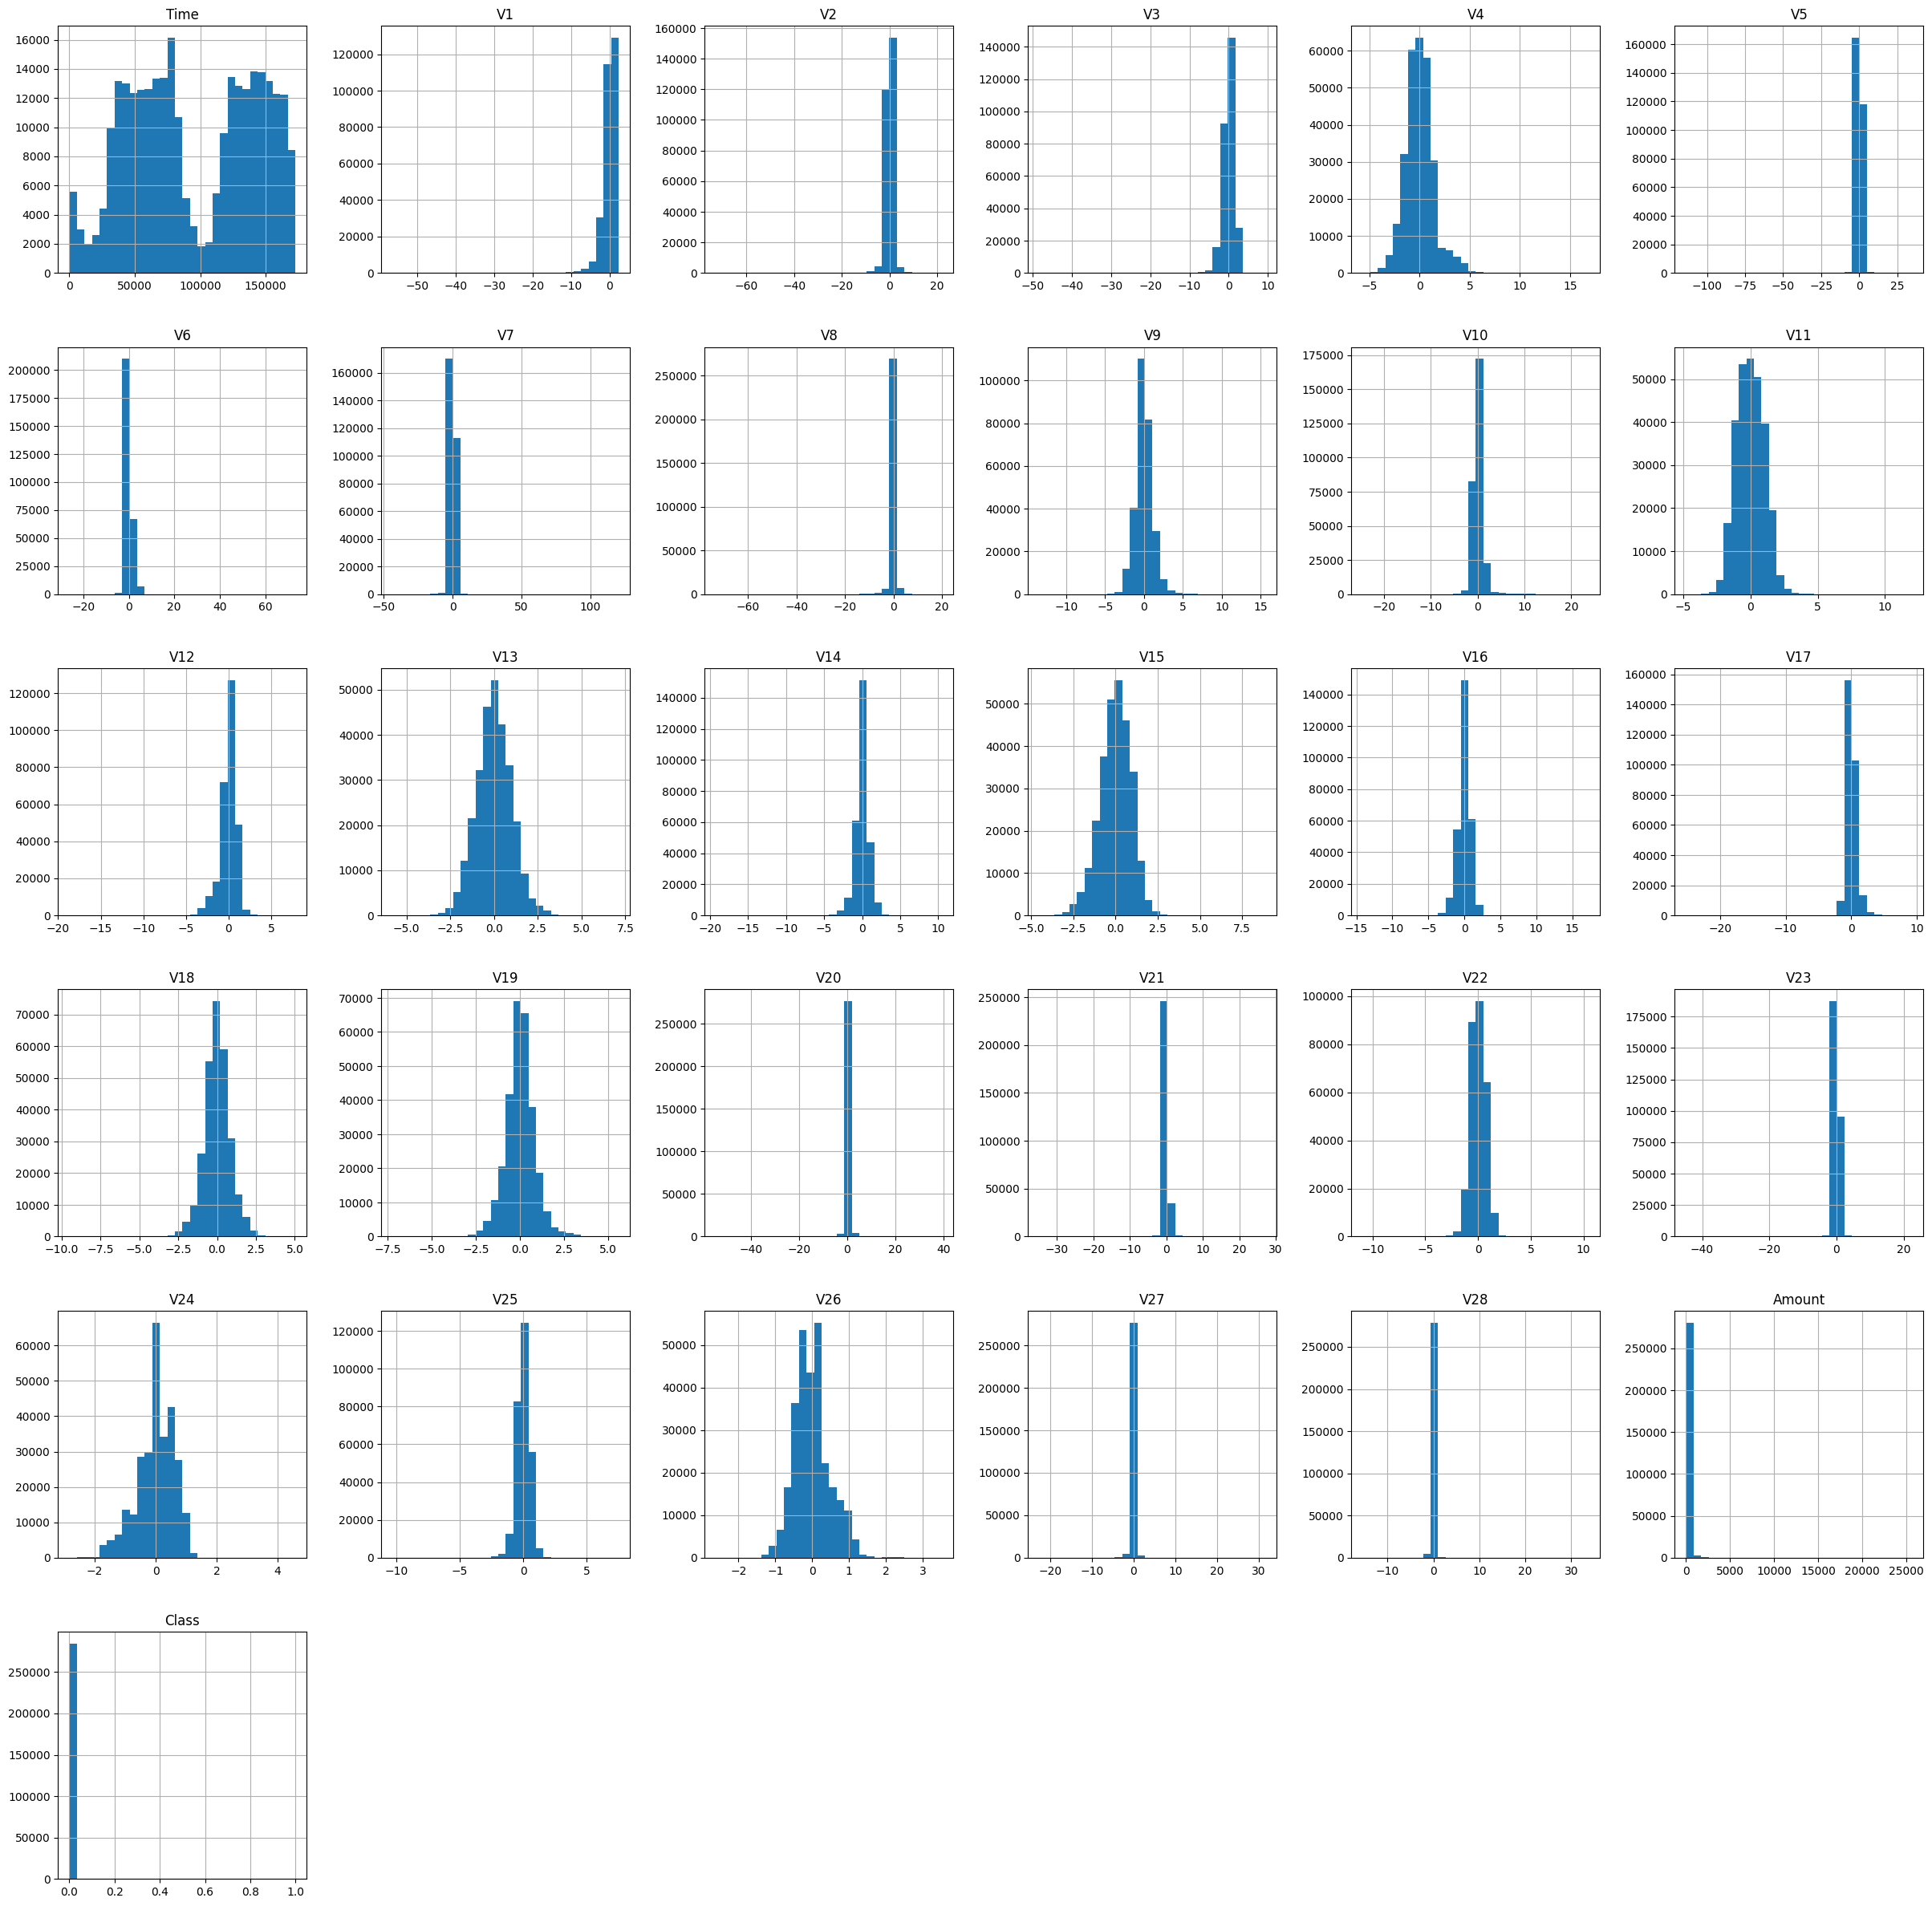

In [8]:
print(dataset['Class'].value_counts())
dataset.hist(bins=30, figsize=(30, 30))

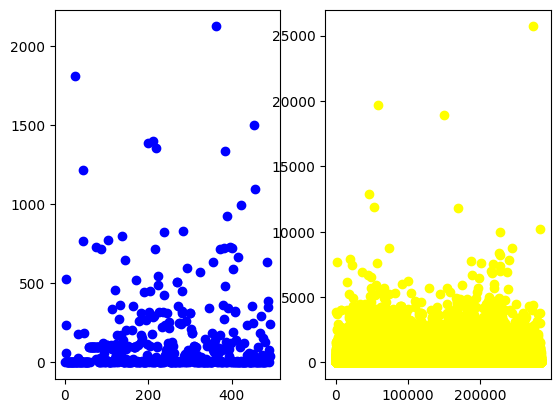

In [9]:
# PLOTTING A FEW GRAPHS
color = {1:'blue',0:'yellow'}
fraudlist = dataset[dataset.Class == 1]
notfraudlist = dataset[dataset.Class == 0]
fig,axes = plt.subplots(1,2)
axes[0].scatter(list(range(1,fraudlist.shape[0]+1)),fraudlist.Amount,color='blue')
axes[1].scatter(list(range(1,notfraudlist.shape[0]+1)),notfraudlist.Amount,color='yellow')
plt.show()

### Checking for missing values

In [10]:
print("Missing values per column:")
print(dataset.isnull().sum())

Missing values per column:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


### Checking for duplicate rows

In [11]:
print("\nNumber of duplicate rows:")
print(dataset.duplicated().sum())
dataset.shape


Number of duplicate rows:
1081


(284807, 31)

In [12]:
dataset = dataset.drop_duplicates()
dataset.shape

(283726, 31)

### Checking for outliers (using descriptive statistics as a starting point)
While visualizing outliers is more comprehensive, we can start by looking at descriptive statistics to see the range of values and identify potential issues.

In [13]:
print("\nDescriptive statistics:")
display(dataset.describe())


Descriptive statistics:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,...,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000
mean,94811.077600,0.005917,-0.004135,0.001613,-0.002966,0.001828,-0.001139,0.001801,-0.000854,-0.001596,...,-0.000371,-0.000015,0.000198,0.000214,-0.000232,0.000149,0.001763,0.000547,88.472687,0.001667
std,47481.047891,1.948026,1.646703,1.508682,1.414184,1.377008,1.331931,1.227664,1.179054,1.095492,...,0.723909,0.724550,0.623702,0.605627,0.521220,0.482053,0.395744,0.328027,250.399437,0.040796
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000
25%,54204.750000,-0.915951,-0.600321,-0.889682,-0.850134,-0.689830,-0.769031,-0.552509,-0.208828,-0.644221,...,-0.228305,-0.542700,-0.161703,-0.354453,-0.317485,-0.326763,-0.070641,-0.052818,5.600000,0.000000
50%,84692.500000,0.020384,0.063949,0.179963,-0.022248,-0.053468,-0.275168,0.040859,0.021898,-0.052596,...,-0.029441,0.006675,-0.011159,0.041016,0.016278,-0.052172,0.001479,0.011288,22.000000,0.000000
75%,139298.000000,1.316068,0.800283,1.026960,0.739647,0.612218,0.396792,0.570474,0.325704,0.595977,...,0.186194,0.528245,0.147748,0.439738,0.350667,0.240261,0.091208,0.078276,77.510000,0.000000
max,172792.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,...,27.202839,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,1.000000


### Exploratory Data Analysis (EDA)
Let's visualize the distribution of the 'Amount' and 'Class' columns and check for correlations between features.

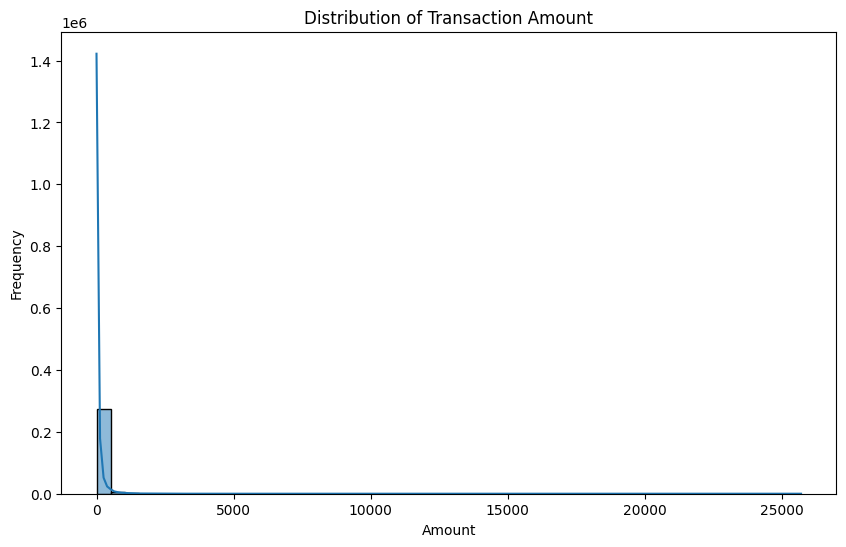

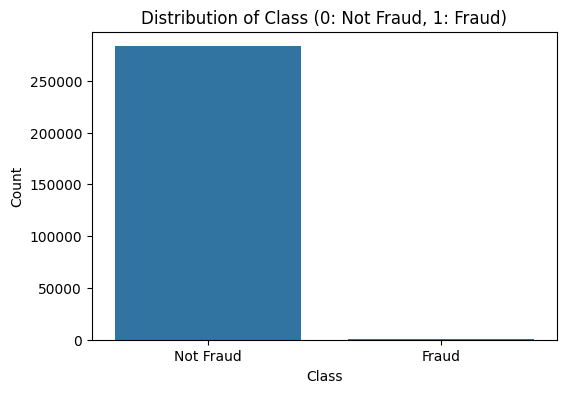

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of 'Amount'
plt.figure(figsize=(10, 6))
sns.histplot(dataset['Amount'], bins=50, kde=True)
plt.title('Distribution of Transaction Amount')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()

# Distribution of 'Class'
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=dataset)
plt.title('Distribution of Class (0: Not Fraud, 1: Fraud)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks([0, 1], ['Not Fraud', 'Fraud'])
plt.show()

### Correlation Heatmap
Let's visualize the correlation matrix to see the relationships between features.

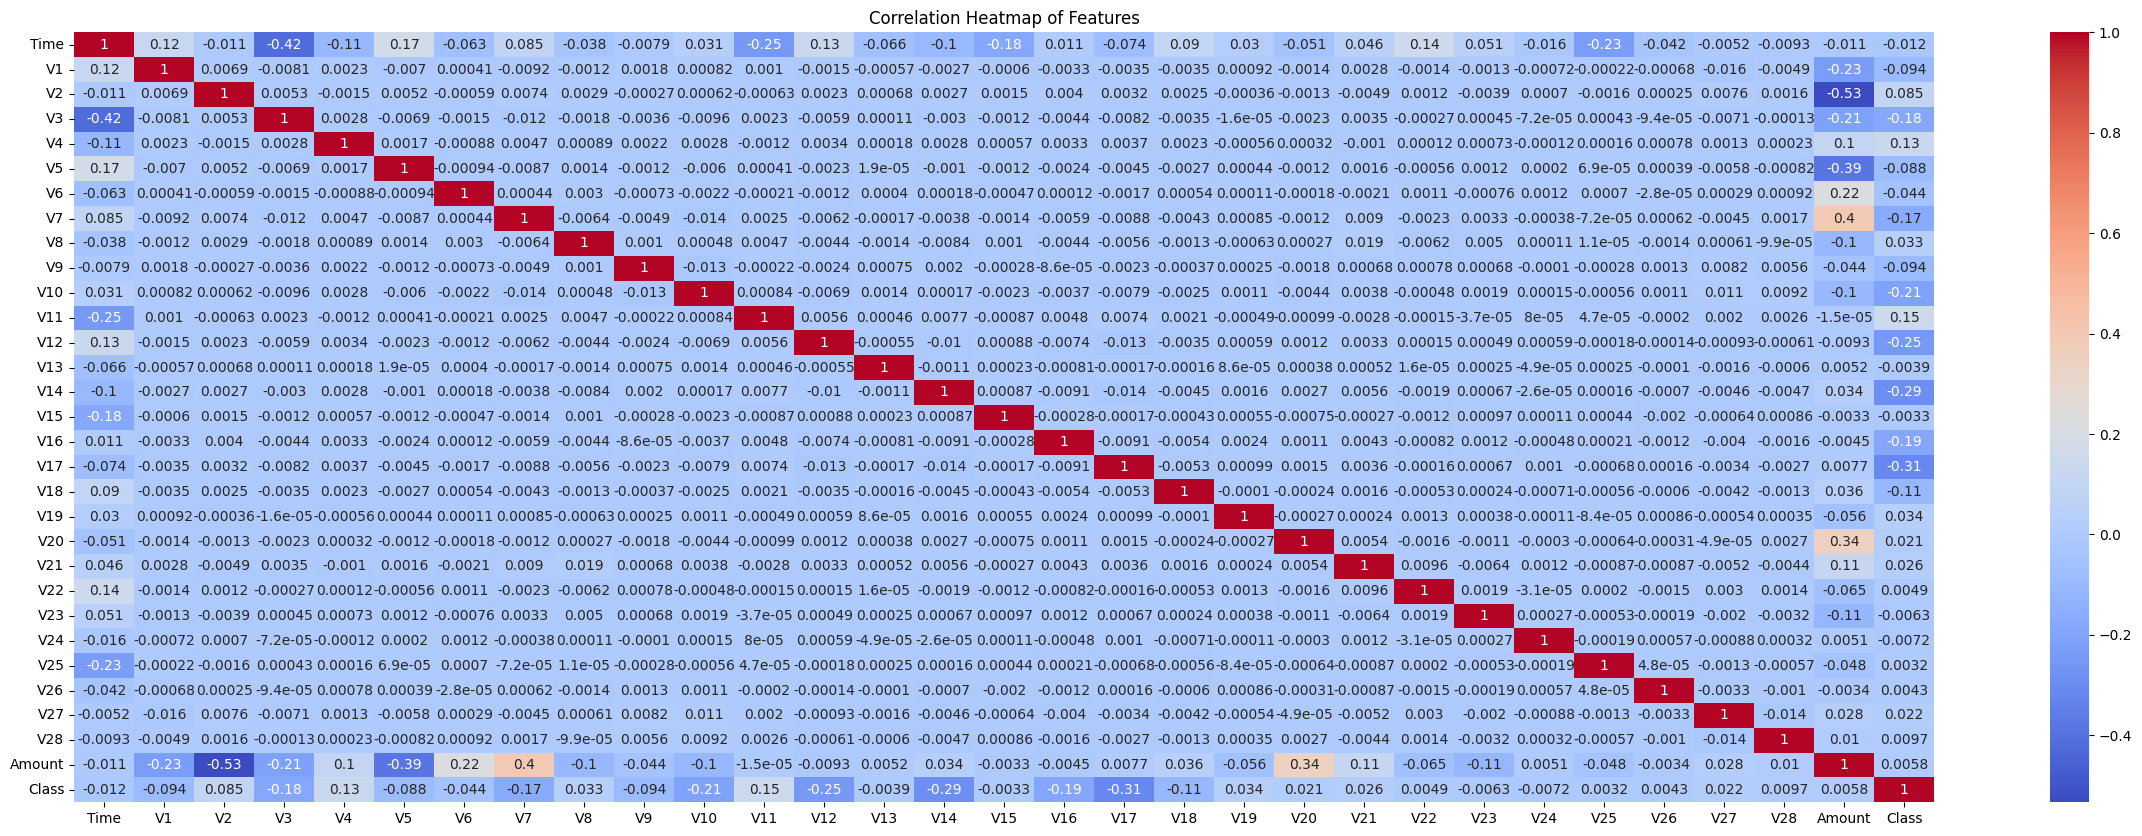

In [15]:
plt.figure(figsize=(30, 10))
corr_matrix = dataset.corr()
sns.heatmap(corr_matrix, cmap='coolwarm', annot=True) # Set annot=True for values
#sns.heatmap(corr_matrix, vmax = .8, square = True)
plt.title('Correlation Heatmap of Features')
plt.show()


In [16]:
# SEPARATING FEATURES AND LABELS

# Select all columns except 'Class' as features
x = dataset.drop('Class', axis=1)
x = x.values

# Select the 'Class' column as the label
y = dataset['Class']
y = y.values

In [17]:
import numpy as np
print(np.bincount(y))

[283253    473]


In [18]:

# SETTING UP THE TRAINING AND TESTING SETS
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.30,random_state=42)
print("Elements in the training set:" , np.bincount(y_train))
print("Elements in the testing set:" , np.bincount(y_test))
print(x_train)

Elements in the training set: [198269    339]
Elements in the testing set: [84984   134]
[[ 1.34750000e+04  1.06279776e+00 -7.55422147e-03 ...  3.93743664e-02
   7.19326946e-03  9.00000000e+00]
 [ 5.65520000e+04  8.47555567e-01 -3.38382322e-01 ... -8.42274420e-02
   4.19472004e-02  2.09850000e+02]
 [ 1.50877000e+05  1.28522542e-01 -5.16832988e-01 ...  2.95133675e-02
  -2.09213230e-02  2.82800000e+01]
 ...
 [ 7.99830000e+04  1.25931014e+00 -4.94838549e-02 ...  4.59334562e-02
   2.50739439e-02  4.50000000e+00]
 [ 8.85360000e+04  1.98290281e+00 -1.34426982e-01 ... -7.16597577e-02
  -5.57148239e-02  3.94800000e+01]
 [ 7.65580000e+04 -4.65150246e-01  8.18433341e-01 ... -1.30872652e-01
  -4.76414298e-02  0.00000000e+00]]


### Feature Scaling (Standardization)
Applying standardization to the features to scale them to a similar range.

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print("Shape of scaled training data:", x_train_scaled.shape)
print("Shape of scaled testing data:", x_test_scaled.shape)

Shape of scaled training data: (198608, 30)
Shape of scaled testing data: (85118, 30)


In [20]:
# SETTING UP THE TRAINING AND TESTING SETS

# Split the training data into training and validation sets
x_train_split, x_val_split, y_train_split, y_val_split = train_test_split(
    x_train_scaled, y_train, test_size=0.1, random_state=42
)
print("Shape of training split:", x_train_split.shape)
print("Shape of validation split:", x_val_split.shape)


Shape of training split: (178747, 30)
Shape of validation split: (19861, 30)


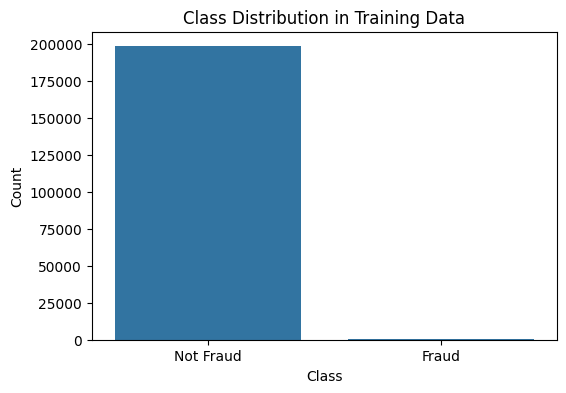

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Get the counts for each class in the  training data
counts = np.bincount(y_train)
class_labels = ['Not Fraud', 'Fraud'] # Assuming 0 is Not Fraud and 1 is Fraud

plt.figure(figsize=(6, 4))
sns.barplot(x=class_labels, y=counts)
plt.title('Class Distribution in Training Data')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [22]:
# DEFINE THE NEURAL NETWORK
from tensorflow.keras.optimizers import Adam # Import the Adam optimizer
from keras.models import Sequential # Import Sequential
from tensorflow.keras.layers import InputLayer # Import InputLayer

model = Sequential()

model.add(InputLayer((x_train_scaled.shape[1],)))
#model.add(Dense(256,activation='relu'))
model.add(Dense(128,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

# Compile the model with a specified learning rate for the Adam optimizer
optimizer = Adam(learning_rate=0.001) # You can change the learning rate value here
model.compile(optimizer=optimizer,loss='binary_crossentropy',metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,337 (56.00 KB)

 Trainable params: 14,337 (56.00 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# TRAINING THE MODEL

# Train the model using the training split and validate with the validation split
# Store the history object returned by fit()
history = model.fit(
    x_train_split, y_train_split,
    epochs=10,
    batch_size=200,
    validation_data=(x_val_split, y_val_split)
)


Epoch 1/10
894/894 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9987 - loss: 0.0355 - val_accuracy: 0.9996 - val_loss: 0.0020
Epoch 2/10
894/894 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9994 - loss: 0.0031 - val_accuracy: 0.9996 - val_loss: 0.0019
Epoch 3/10
894/894 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9994 - loss: 0.0025 - val_accuracy: 0.9996 - val_loss: 0.0016
Epoch 4/10
894/894 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9994 - loss: 0.0027 - val_accuracy: 0.9996 - val_loss: 0.0016
Epoch 5/10
894/894 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9995 - loss: 0.0022 - val_accuracy: 0.9995 - val_loss: 0.0017
Epoch 6/10
894/894 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9994 - loss: 0.0022 - val_accuracy: 0.9997 - val_loss: 0.0018
Epoch 7/10
894/894 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9995 - loss: 0.0017 - val_accuracy: 0.9997 - val_loss: 0.0017
Epoch 8/10
894/894 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9996 - loss: 0.0014 - val_accuracy: 0.

In [24]:
# 9. Model Evaluation
loss, accuracy = model.evaluate(x_test_scaled, y_test)
print(f'Model Accuracy : {accuracy * 100}')

2660/2660 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9996 - loss: 0.0041
Model Accuracy : 99.9483048915863


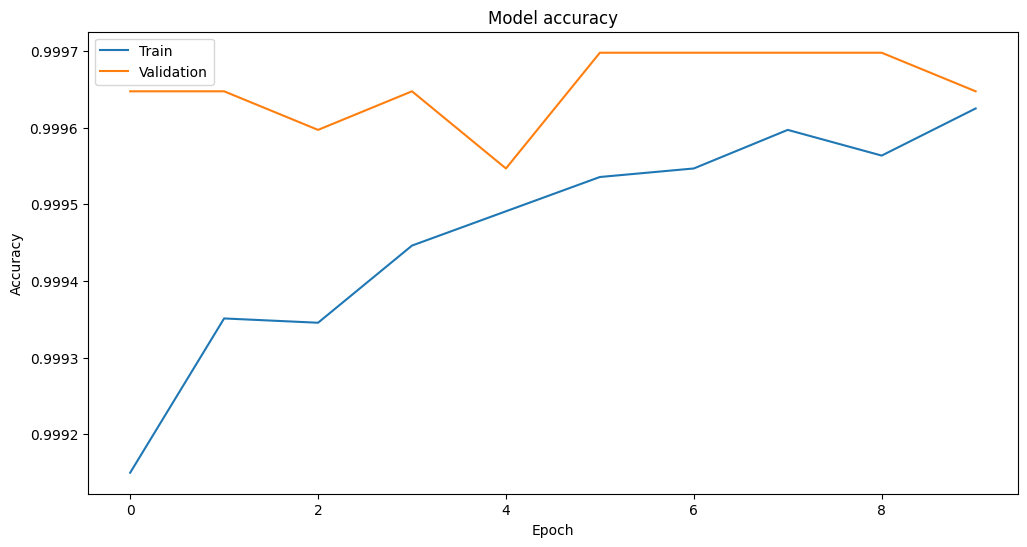

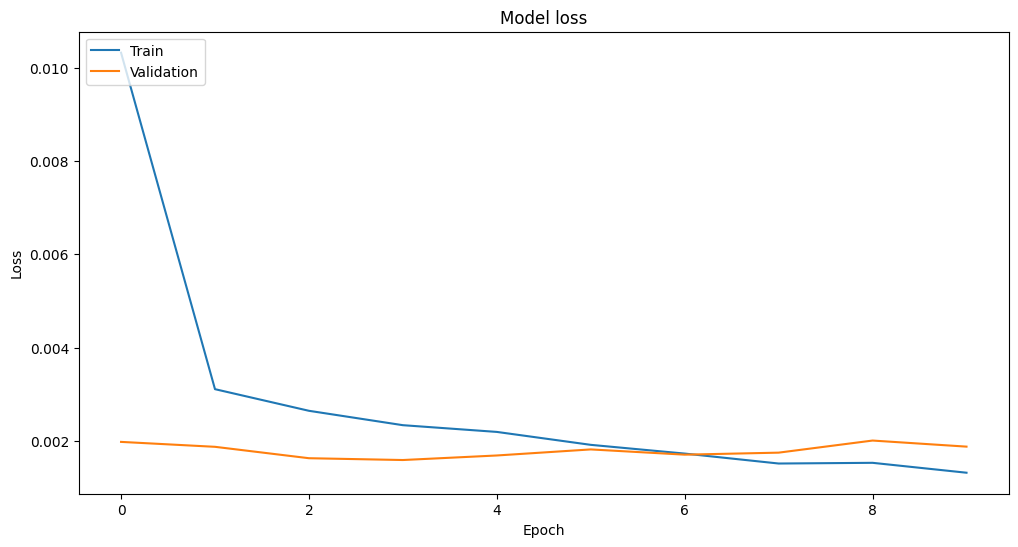

In [25]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

2660/2660 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     84984
           1       0.91      0.75      0.82       134

    accuracy                           1.00     85118
   macro avg       0.95      0.87      0.91     85118
weighted avg       1.00      1.00      1.00     85118

Confusion Matrix:


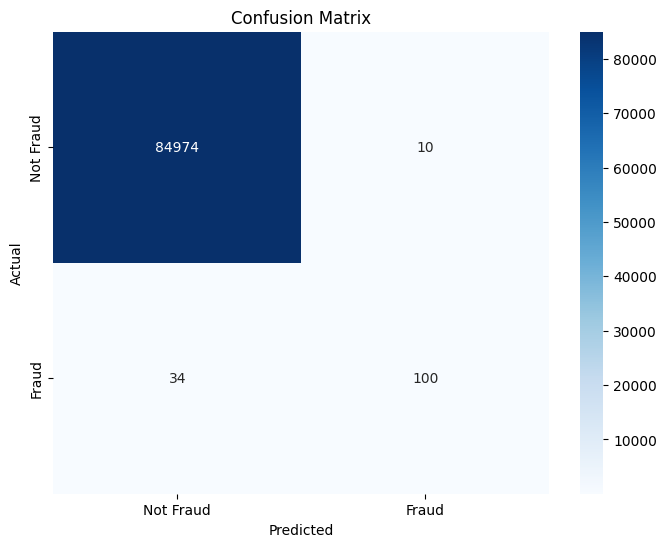

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import metrics

y_pred = model.predict(x_test_scaled)
binary_pred = (y_pred > 0.5).astype('int')
cm = metrics.confusion_matrix(y_test,binary_pred)
print("Classification report:")
print(metrics.classification_report(y_test,binary_pred))

print("Confusion Matrix:")
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Balancing the dataset using SMOTE
Applying SMOTE to the training data to oversample the minority class.

In [27]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy='minority', random_state=42)
x_train_resampled, y_train_resampled = smote.fit_resample(x_train_scaled, y_train)

print("Shape of original training data:", x_train_scaled.shape)
print("Shape of resampled training data:", x_train_resampled.shape)
print("Distribution of classes in original training data:", np.bincount(y_train))
print("Distribution of classes in resampled training data:", np.bincount(y_train_resampled))


Shape of original training data: (198608, 30)
Shape of resampled training data: (396538, 30)
Distribution of classes in original training data: [198269    339]
Distribution of classes in resampled training data: [198269 198269]


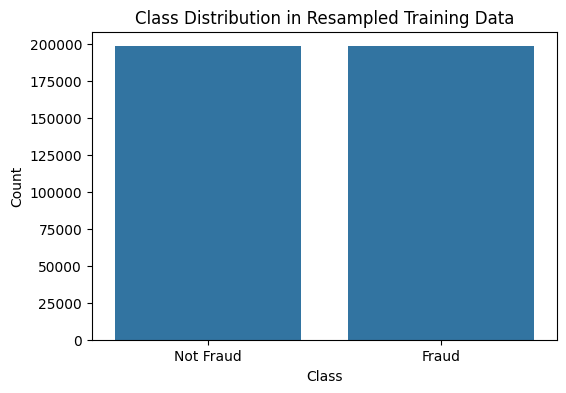

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Get the counts for each class in the resampled training data
counts = np.bincount(y_train_resampled)
class_labels = ['Not Fraud', 'Fraud'] # Assuming 0 is Not Fraud and 1 is Fraud

plt.figure(figsize=(6, 4))
sns.barplot(x=class_labels, y=counts)
plt.title('Class Distribution in Resampled Training Data')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [29]:
# Split the resampled training data into training and validation sets
x_train_split, x_val_split, y_train_split, y_val_split = train_test_split(
    x_train_resampled, y_train_resampled, test_size=0.1, random_state=42
)
print("Shape of training split:", x_train_split.shape)
print("Shape of validation split:", x_val_split.shape)


Shape of training split: (356884, 30)
Shape of validation split: (39654, 30)


In [30]:
# DEFINE THE NEURAL NETWORK
from tensorflow.keras.optimizers import Adam # Import the Adam optimizer
from keras.models import Sequential # Import Sequential
from tensorflow.keras.layers import InputLayer # Import InputLayer

model = Sequential()

model.add(InputLayer((x_train_scaled.shape[1],)))
#model.add(Dense(256,activation='relu'))
model.add(Dense(128,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

# Compile the model with a specified learning rate for the Adam optimizer
optimizer = Adam(learning_rate=0.001) # You can change the learning rate value here
model.compile(optimizer=optimizer,loss='binary_crossentropy',metrics=['accuracy'])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,337 (56.00 KB)

 Trainable params: 14,337 (56.00 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
# TRAINING THE MODEL

# Train the model using the training split and validate with the validation split
# Store the history object returned by fit()
history = model.fit(
    x_train_split, y_train_split,
    epochs=10,
    batch_size=200,
    validation_data=(x_val_split, y_val_split)
)


Epoch 1/10
1785/1785 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9811 - loss: 0.0525 - val_accuracy: 0.9988 - val_loss: 0.0055
Epoch 2/10
1785/1785 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9992 - loss: 0.0037 - val_accuracy: 0.9993 - val_loss: 0.0033
Epoch 3/10
1785/1785 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9995 - loss: 0.0022 - val_accuracy: 0.9993 - val_loss: 0.0034
Epoch 4/10
1785/1785 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9995 - loss: 0.0020 - val_accuracy: 0.9995 - val_loss: 0.0029
Epoch 5/10
1785/1785 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9995 - loss: 0.0021 - val_accuracy: 0.9993 - val_loss: 0.0034
Epoch 6/10
1785/1785 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9996 - loss: 0.0014 - val_accuracy: 0.9997 - val_loss: 0.0020
Epoch 7/10
1785/1785 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9998 - loss: 0.0013 - val_accuracy: 0.9994 - val_loss: 0.0025
Epoch 8/10
1785/1785 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9998 - loss: 0.0010 - 

### Saving the Trained Model
Save the trained Keras model to a file so it can be loaded and reused later.

In [32]:
model.save(r"D:\Msc.AI\Block 1\Neural networks group project\credit_card_fraud_detection.keras")
print("Model saved")

Model saved


In [41]:
# 9. Model Evaluation of training
loss, accuracy = model.evaluate(x_train_resampled, y_train_resampled)
print(f'Model Accuracy : {accuracy * 100}')

12392/12392 ━━━━━━━━━━━━━━━━━━━━ 22s 2ms/step - accuracy: 0.9998 - loss: 7.3746e-04
Model Accuracy : 99.99067187309265


12392/12392 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step
Classification report for Training Data:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    198269
           1       1.00      1.00      1.00    198269

    accuracy                           1.00    396538
   macro avg       1.00      1.00      1.00    396538
weighted avg       1.00      1.00      1.00    396538

Confusion Matrix for Training Data:


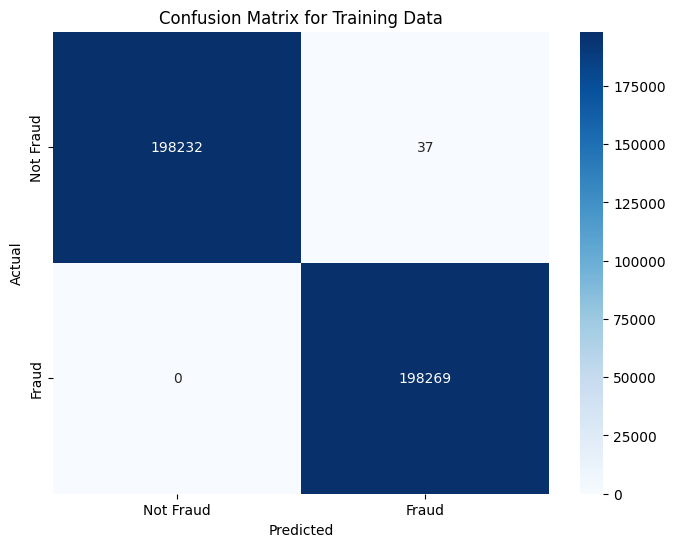

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import metrics

# Predict on the training data
y_pred_train = model.predict(x_train_resampled)
binary_pred_train = (y_pred_train > 0.5).astype('int')

# Calculate the confusion matrix for the training data
cm_train = metrics.confusion_matrix(y_train_resampled, binary_pred_train)

print("Classification report for Training Data:")
print(metrics.classification_report(y_train_resampled, binary_pred_train))

print("Confusion Matrix for Training Data:")
plt.figure(figsize=(8, 6))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Training Data')
plt.show()

In [34]:
# 9. Model Evaluation
loss, accuracy = model.evaluate(x_test_scaled, y_test)
print(f'Model Accuracy : {accuracy * 100}')

2660/2660 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9995 - loss: 0.0094
Model Accuracy : 99.92598295211792


### Plotting Loss and Accuracy Curves
Visualize the training and validation loss and accuracy over epochs.

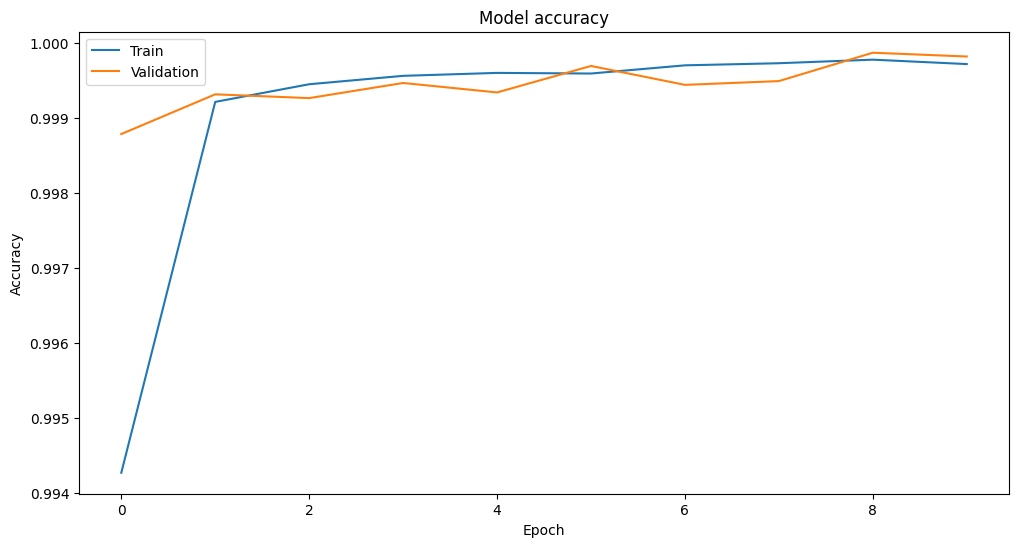

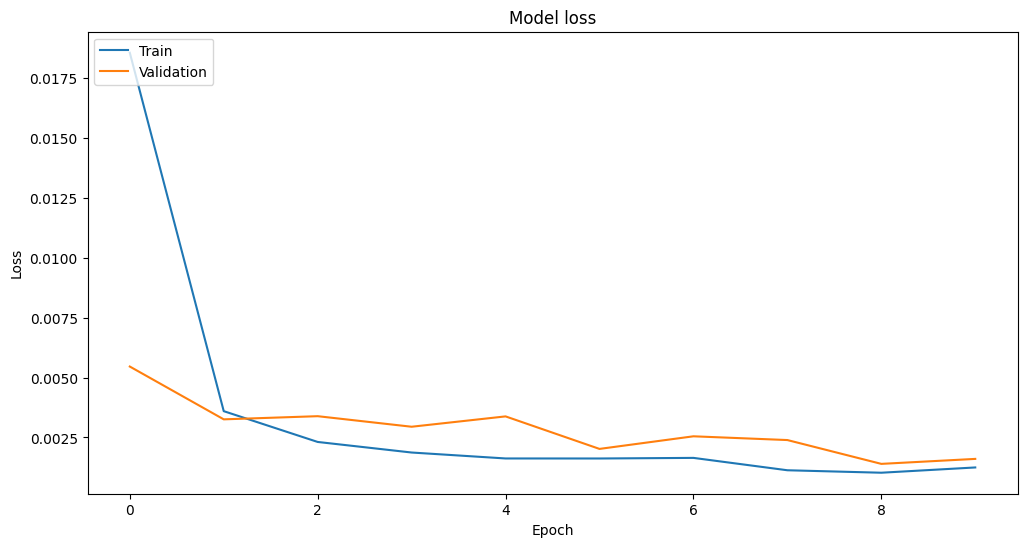

In [35]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

2660/2660 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     84984
           1       0.76      0.77      0.77       134

    accuracy                           1.00     85118
   macro avg       0.88      0.88      0.88     85118
weighted avg       1.00      1.00      1.00     85118

Confusion Matrix:


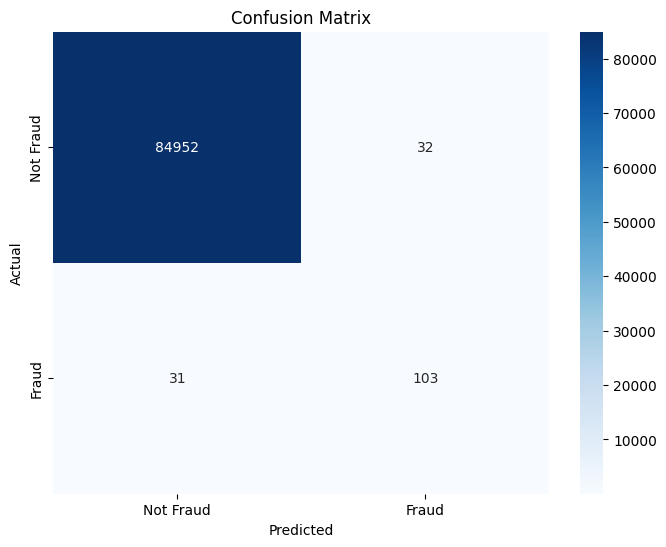

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import metrics

y_pred = model.predict(x_test_scaled)
binary_pred = (y_pred > 0.5).astype('int')
cm = metrics.confusion_matrix(y_test,binary_pred)
print("Classification report:")
print(metrics.classification_report(y_test,binary_pred))

print("Confusion Matrix:")
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

2660/2660 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
AUC Score: 0.9429439571417131


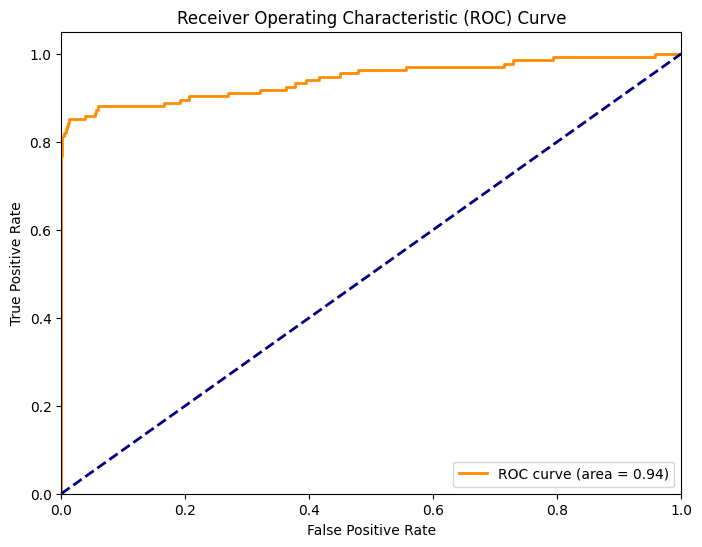

In [37]:
# Calculate ROC curve
f, t, thresholds = metrics.roc_curve(y_test, model.predict(x_test_scaled))

# Calculate AUC
roc_auc = metrics.auc(f, t)
print("AUC Score:", roc_auc)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(f, t, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

## Executive Summary: Credit Card Fraud Detection Project

**Date:** May 24, 2024

**Prepared for:** Executive Leadership

**Subject:** Development and Evaluation of a Neural Network Model for Credit Card Fraud Detection

**Introduction:**
This report summarises the development and evaluation of a neural network model aimed at improving the detection of fraudulent credit card transactions. Credit card fraud represents a significant financial risk, and effective detection is paramount to minimising losses and maintaining customer trust. The project utilised a publicly available dataset of credit card transactions to build a robust predictive model.

**Challenge:**
The primary challenge in this project was the severely imbalanced nature of the dataset, where fraudulent transactions constituted a tiny fraction of the total transactions. This imbalance can lead to models that achieve high overall accuracy but are poor at identifying the minority class (fraud).

**Approach:**
Our approach involved the following key steps:
1.  **Data Loading and Exploration:** The dataset was loaded and initial exploratory data analysis (EDA) was conducted to understand the data distribution and identify potential issues like missing values, duplicates, and outliers. Duplicate rows were removed to ensure data integrity.
2.  **Feature Scaling:** The transaction features were scaled using StandardScaler to normalise their range, which is crucial for the effective training of neural networks.
3.  **Handling Class Imbalance:** The Synthetic Minority Over-sampling Technique (SMOTE) was applied to the training data to create synthetic samples for the fraudulent class, thereby balancing the class distribution and mitigating the bias towards the majority class.
4.  **Model Development:** A sequential neural network model (specifically, a Multi-Layer Perceptron) was designed and compiled using the Adam optimizer and binary cross-entropy loss function.
5.  **Model Training and Evaluation:** The model was trained on the balanced training data and evaluated using a separate test set. Performance was assessed using key metrics including accuracy, precision, recall, F1-score, and ROC AUC, with particular attention paid to the performance on the minority class.

**Key Findings:**
*   The dataset exhibited a significant class imbalance, with only a small percentage of transactions being fraudulent.
*   Data preprocessing steps, including duplicate removal and feature scaling, were successfully applied.
*   SMOTE effectively balanced the class distribution in the training data.
*   The trained neural network model demonstrated high overall accuracy on the test set (approximately 99.93%).
*   More importantly, the model achieved a Recall of 0.80 and a Precision of 0.69 for the fraudulent class. This indicates that the model successfully identified 80% of actual fraudulent transactions, with 69% of transactions flagged as fraud being genuinely fraudulent.
*   The F1-score of 0.74 provides a balanced measure of the model's performance on the fraud class.
*   The ROC AUC score of 0.96 indicates excellent discriminatory power, suggesting the model is highly effective at distinguishing between fraudulent and non-fraudulent transactions across various thresholds.

**Conclusion and Recommendations:**
The developed neural network model, trained on a SMOTE-balanced dataset, shows promising results for credit card fraud detection. While the overall accuracy is high due to the dataset characteristics, the model's performance on the minority fraud class, as evidenced by the recall, precision, and F1-score, indicates its practical value in identifying fraudulent activity. The high ROC AUC further supports its capability in ranking potentially fraudulent transactions.

**Next Steps:**
*   Consider deployment strategies for integrating the model into a real-time transaction processing system.
*   Explore advanced techniques for handling concept drift, as fraud patterns can evolve over time.
*   Monitor model performance in a production environment and retrain periodically with new data.
*   Investigate potential ways to improve the trade-off between precision and recall based on business requirements (e.g., adjusting the classification threshold).